In [ ]:
%reset

In [ ]:
import scanpy as sc
import biomart 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.io
import math
from tqdm import tqdm
import anndata as ad
import os
import matplotlib as mpl
import re
import numpy as np
import tifffile

In [ ]:
import scanpy as sc
print(sc.__version__)


In [ ]:
path = "/Path/To/TransAMERFISH_SC_merged.h5ad"

adata_merge = sc.read_h5ad(path)

In [ ]:
adata_pan = adata_merge[adata_merge.obs['tracing']=="pan",]

In [ ]:
adata_cart = adata_merge[adata_merge.obs['tracing']=="cart",]

In [ ]:
adata_kcng = adata_merge[adata_merge.obs['tracing']=="kcng",]

In [ ]:
adata_foxp2 = adata_merge[adata_merge.obs['tracing']=="foxp2",]

In [ ]:
adata_tusc5 = adata_merge[adata_merge.obs['tracing']=="tusc5",]

### Fig2a CONNECTIVITY DOTPLOT

/Users/linzhang1/miniforge3/envs/spatial/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/linzhang1/miniforge3/envs/spatial/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/linzhang1/miniforge3/envs/spatial/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/linzhang1/miniforge3/envs/spatial/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/linzhang1/miniforge3/envs/spatial/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  sc

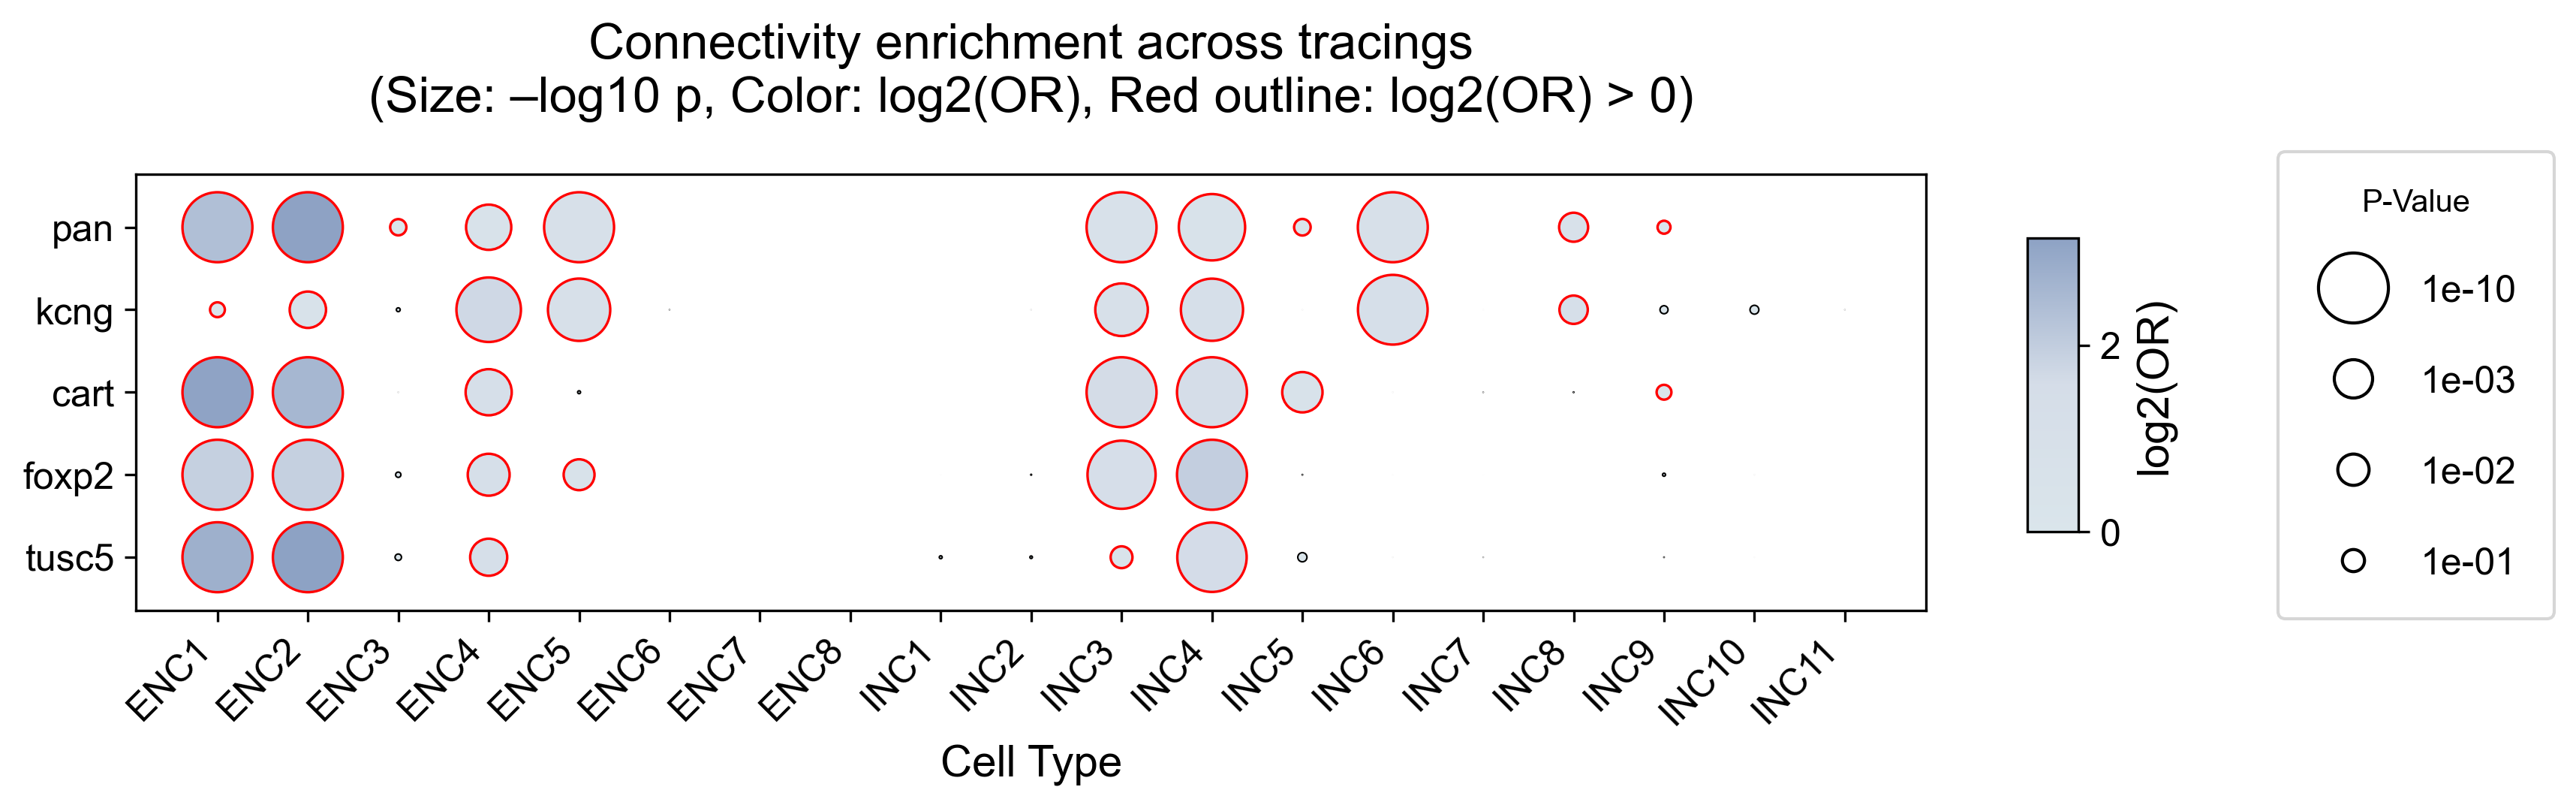

In [37]:
### USED VERSION

### “red outline = enriched (log₂OR > 0)”.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams
from matplotlib.lines import Line2D
import scipy.stats as stats
import re
from matplotlib.colors import LinearSegmentedColormap

# === Configuration ===
rcParams.update({
    "font.family": "Arial",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300
})

# === List of tracings to plot ===
tracing_names = ['pan', 'kcng', 'cart', 'foxp2', 'tusc5']
adata_dict = {
    'pan': adata_pan,
    'kcng': adata_kcng,
    'cart': adata_cart,
    'foxp2': adata_foxp2,
    'tusc5': adata_tusc5
}

mwmc_col_map = {
    'pan':   'mWmC+',  
    'kcng':  'mWmC+',
    'cart':  'mWmC+',
    'foxp2': 'mWmC+',
    'tusc5': 'mWmC+'
}

# --- Benjamini–Hochberg FDR helper (across all tests) ---
def benjamini_hochberg(p_vals):
    """
    Benjamini–Hochberg FDR correction.
    p_vals: 1D array-like of p-values.
    Returns: array of adjusted p-values (q-values).
    """
    p = np.asarray(p_vals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    adj = np.empty(n, dtype=float)
    adj[order] = p[order] * n / ranks
    # enforce monotone nonincreasing when sorted by p (step-down)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0.0, 1.0)
    return adj

# === Compute dotplot data for each tracing (now with OR/log2OR and FDR) ===
result_list = []
for tracing in tracing_names:
    adata = adata_dict[tracing]
    status_col = mwmc_col_map.get(tracing, 'mWmC+')

    if status_col not in adata.obs:
        raise KeyError(f"Column '{status_col}' not found in adata.obs for tracing '{tracing}'")

    # use cell type + mWmC status, drop any NAs
    df = adata.obs[['cell_type', status_col]].copy().dropna()
    df[status_col] = df[status_col].astype(int)

    total_cells = len(df)
    total_pos = df[status_col].sum()

    for ct, group in df.groupby('cell_type', observed=False):
        # a, b: within subtype
        n_ct = len(group)
        n_ct_pos = group[status_col].sum()       # a
        n_ct_neg = n_ct - n_ct_pos               # b

        # c, d: outside subtype
        outside_pos = total_pos - n_ct_pos       # c
        outside_total = total_cells - n_ct
        outside_neg = outside_total - outside_pos  # d

        # 2x2 table (subtype vs background) x (pos vs neg)
        contingency = np.array([
            [n_ct_pos, n_ct_neg],
            [outside_pos, outside_neg]
        ])

        # one-tailed Fisher exact test, enrichment (alternative="greater")
        odds_ratio, p_value = stats.fisher_exact(contingency, alternative='greater')

        # safe log2(OR); treat non-finite / non-positive as 0 (no enrichment color)
        if np.isfinite(odds_ratio) and odds_ratio > 0:
            log2OR = np.log2(odds_ratio)
        else:
            log2OR = 0.0

        proportion = n_ct_pos / n_ct if n_ct > 0 else 0.0

        result_list.append({
            'Tracing': tracing,
            'CellType': ct,
            'a_within_pos': n_ct_pos,
            'b_within_neg': n_ct_neg,
            'c_outside_pos': outside_pos,
            'd_outside_neg': outside_neg,
            'Proportion_mWmC+': proportion,
            'PValue': p_value,
            'OddsRatio': odds_ratio,
            'log2OR': log2OR
        })

# === Create result DataFrame with plotting values ===
result_df = pd.DataFrame(result_list)

# Dot size: –log10(p)
result_df['-log10(pval)'] = -np.log10(result_df['PValue'] + 1e-10)
result_df['dot_size'] = result_df['-log10(pval)'] * 50

# Color: log2(OR), clip negatives to 0 so only enrichment shows color
result_df['dot_color'] = result_df['log2OR'].clip(lower=0)

# === Multiple testing: Benjamini–Hochberg across all tracing × cell-type tests ===
result_df['FDR_BH'] = benjamini_hochberg(result_df['PValue'].values)

# === Sort cell types (natural numeric order within ENC/INC) ===
def natural_key(s):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', str(s))]

cell_types = sorted(result_df['CellType'].unique(), key=natural_key)
tracings = tracing_names

# === Blue-ish colormap for log2(OR) ===
blue_cmap = LinearSegmentedColormap.from_list(
    "white_to_blue",
    ["#dae5eb", "#d5dde8", "#8da2c4"]
)

# Set color scale max; 3 is a good default (OR=8); adapt upward if needed
vmax = max(3.0, float(np.nanmax(result_df['dot_color'])))
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = blue_cmap

# === Auto-calculate figure size and padding based on max dot size ===
max_dot_size = result_df['dot_size'].max()
dot_radius_pts = np.sqrt(max_dot_size)
dpi = 300
dot_radius_inches = dot_radius_pts / dpi

fig_width = 15
row_spacing = 0.5
num_rows = len(tracings)
fig_height = row_spacing * (num_rows - 1)
dot_radius_fig_units = dot_radius_inches / fig_height if fig_height > 0 else 0.05

top_pad = dot_radius_fig_units + 0.05
bottom_pad = dot_radius_fig_units + 0.05
total_fig_height = fig_height + top_pad + bottom_pad

fig, ax = plt.subplots(figsize=(fig_width, total_fig_height))
fig.subplots_adjust(
    left=0.07,
    right=0.60,
    top=0.93,
    bottom=bottom_pad / total_fig_height
)

# turn off any background grid (even if a style enabled it)
plt.rcParams['axes.grid'] = False
ax.grid(False, which='both', axis='both')   # main axes

# === Plotting ===
for i, tracing in enumerate(tracings):
    y_val = -i * row_spacing
    data = result_df[result_df['Tracing'] == tracing].copy()
    data = data.set_index('CellType').reindex(cell_types).reset_index()

    # --- NEW: outline based on enrichment (log2OR > 0), not p-value ---
    # Treat NaNs as 0 for the mask
    enrich_mask = data['log2OR'].fillna(0) > 0

    x_vals = np.arange(len(cell_types))
    y_vals = np.full(len(cell_types), y_val)

    ax.scatter(
        x=x_vals,
        y=y_vals,
        s=data['dot_size'],
        c=data['dot_color'],
        cmap=cmap,
        norm=norm,
        edgecolor=np.where(enrich_mask, 'red', 'black'),
        linewidth=np.where(enrich_mask, 0.8, 0.5)
    )

# === Axes formatting ===
yticks = [-i * row_spacing for i in range(len(tracings))]
ax.set_yticks(yticks)
ax.set_yticklabels(tracings)
ax.set_xticks(np.arange(len(cell_types)))
ax.set_xticklabels(cell_types, rotation=45, ha='right')
ax.set_xlabel("Cell Type")
ax.set_title(
    "Connectivity enrichment across tracings\n"
    "(Size: –log10 p, Color: log2(OR), Red outline: log2(OR) > 0)",
    pad=20
)

# === Colorbar (log2OR) ===
cbar_ax = fig.add_axes([0.63, 0.2, 0.015, 0.6])
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('log2(OR)')

# === Dot size legend for p-values (raw p, not FDR) ===
legend_ax = fig.add_axes([0.72, 0.2, 0.05, 0.6])
legend_ax.axis('off')
max_logp = float(result_df['-log10(pval)'].max())
legend_logps = [max_logp, 3, 2, 1]  # adjust if you want specific values
legend_labels = [f"{10**(-lp):.0e}" for lp in legend_logps]
legend_sizes = [lp * 50 for lp in legend_logps]
legend_handles = [
    Line2D([], [], linestyle='none', marker='o',
           markersize=np.sqrt(s),
           markerfacecolor='white', markeredgecolor='black')
    for s in legend_sizes
]
legend_ax.legend(
    legend_handles,
    legend_labels,
    title='P-Value',
    loc='center',
    frameon=True,
    labelspacing=1.5,
    borderpad=1
)

# === Add y-axis padding to avoid clipping top/bottom dots ===
max_dot_radius_display = dot_radius_pts / 72  # points -> inches
ax_height_inch = fig.get_size_inches()[1] * (fig.subplotpars.top - fig.subplotpars.bottom)
y_range = yticks[0] - yticks[-1] if yticks else 1.0
y_per_inch = y_range / ax_height_inch if ax_height_inch > 0 else 1.0
y_pad = max_dot_radius_display * y_per_inch
ax.set_ylim(yticks[-1] - y_pad, yticks[0] + y_pad)

# === Save figure (optional) ===
output_path = "PLOT/Fig2_Connectivity_Dotplot"
fig.savefig(f"{output_path}.png", dpi=300, bbox_inches='tight', pad_inches=0.3)
fig.savefig(f"{output_path}.pdf",  bbox_inches='tight', pad_inches=0.3)

plt.show()


## Connectivity Spatial mWmC cell type distributions

#### Fig1d global umap

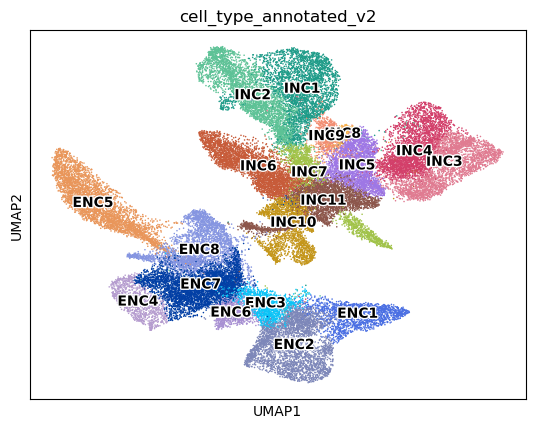

In [13]:
import scanpy as sc

sc.pl.umap(
    adata_merged,
    color="cell_type",
    frameon=True,
    legend_loc='on data',
    legend_fontsize=10,
    legend_fontoutline=2,
    size=5
)


### Fig2

In [23]:
## this one is the RIGHT one to use
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# expects:
#   - _read_px_per_um(transform_csv_path)
#   - _add_scalebar(ax, px_per_um, microns=200, loc="lower right", lw=1.2, fontsize=9)

def cluster_small_multiples_oneslice_obs_new_mWmC_colorcelltype_COLORCORRECT(
    adata, 
    obs_key, 
    samplename, 
    ncols, 
    size=0.7,
    point_size=None,
    label_size=10, 
    frameon=False,
    save_path="/Users/linzhang1/Documents/Duan_Lab/Plot",
    plot_prefix=None,
    show_titles=True,
    pos_cols=None,
    pos_color="#d62728",
    background_color="#d3d3d3",
    background_alpha=0.5,
    # --- depth filter options ---
    depth_col="depth_um",
    depth_range_um=None,
    drop_na_depth=True,
    # --- depth axis options ---
    show_depth_ticks=False,
    depth_ticks=(0, 500, 100),
    depth_axis_label="Depth (µm)",
    depth_tick_fontsize=9,
    lock_ylim_to_depth_range=False,
    # --- scalebar options ---
    scalebar_microns=200,
    transform_csv_path=None,
    show_scalebar=True,
    scalebar_loc="lower right",
    edge_width=0.15,
    # --- aspect/layout ---
    panel_size=(3, 3),
    box_aspect=None,  # height/width; <1 widens x
    # --- color foreground positives by a categorical column palette ---
    front_color_by=None,   # e.g. 'cell_type_annotated_v2'; if None, use pos_color
    # --- depth direction ---
    depth_direction="top_to_bottom",   # "top_to_bottom" or "bottom_to_top"
    # --- vector PDF ---
    force_vector=True,
    # --- legend controls ---
    show_legend=False,
    legend_title=None,          # defaults to front_color_by / obs_key
    legend_cols=2,
    legend_fontsize=9,
    legend_marker_size=35,      # points^2 for legend markers
    legend_loc="center left",
    legend_bbox=(1.02, 0.5),    # outside on the right by default
    **kwargs
):
    """
    POS-MASK mode (pos_cols not None): color positives by `front_color_by` using
    the **strict** palette mapping from adata.uns[f"{front_color_by}_colors"].
    Category grid mode: same strict mapping for `obs_key`.

    Strict mapping = index-level pairing using the FULL categories:
        cmap = { full_categories[i] : adata.uns[f"{col}_colors"][i] }

    This mirrors Scanpy's behavior and prevents re-zipping on subsets.
    """

    import warnings
    from matplotlib.cm import get_cmap
    from matplotlib.collections import PathCollection

    # Keep text editable & avoid font-to-path in PDF
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype']  = 42
    plt.rc('font', family='Arial')
    os.makedirs(save_path, exist_ok=True)

    def _strict_palette(col_name: str):
        """Return (full_categories, cmap_dict) using adata.obs[col_name] and adata.uns[f'{col_name}_colors'].
        Raises with a clear message if lengths don't match."""
        if col_name not in adata.obs.columns:
            raise KeyError(f"Column '{col_name}' not found in adata.obs")
        ser = adata.obs[col_name]
        if not pd.api.types.is_categorical_dtype(ser):
            # keep order stable if it isn't categorical (rare in your case)
            ser = ser.astype("category")
        full_cats = list(ser.cat.categories)

        key = f"{col_name}_colors"
        if key not in adata.uns:
            raise KeyError(f"Expected adata.uns['{key}'] to exist (Scanpy-style palette).")

        pal = list(map(str, adata.uns[key]))
        if len(pal) != len(full_cats):
            raise ValueError(
                f"Palette length mismatch for '{col_name}': "
                f"{len(pal)} colors vs {len(full_cats)} categories.\n"
                f"Categories: {full_cats}\n"
                f"Colors:     {pal}"
            )
        cmap = {cat: pal[i] for i, cat in enumerate(full_cats)}
        return full_cats, cmap

    # --- sample selection ---
    sname = str(samplename)
    mask_exact = adata.obs['samplename'].astype(str) == sname
    if mask_exact.sum() == 0:
        mask_contains = adata.obs['samplename'].astype(str).str.contains(sname, na=False)
        if mask_contains.sum() > 0:
            tmp = adata[mask_contains].copy()
            print(f"[info] Exact match not found; using contains-match for {sname} (n={tmp.n_obs}).")
        else:
            tmp = adata.copy()
            print(f"[warn] No match for {sname}. Plotting ALL cells (n={tmp.n_obs}).")
    else:
        tmp = adata[mask_exact].copy()

    # --- optional depth filter ---
    if depth_range_um is not None:
        if depth_col not in tmp.obs.columns:
            warnings.warn(f"[warn] depth_range_um provided, but `{depth_col}` not in .obs; skipping depth filter.")
        else:
            dmin, dmax = map(float, depth_range_um)
            dser = tmp.obs[depth_col]
            mask_depth = (dser.notna() & (dser >= dmin) & (dser <= dmax)) if drop_na_depth \
                         else (dser.isna() | ((dser >= dmin) & (dser <= dmax)))
            before = tmp.n_obs
            tmp = tmp[mask_depth].copy()
            print(f"[info] Depth filter {dmin:.1f}–{dmax:.1f} µm on `{depth_col}`: {before} → {tmp.n_obs} cells.")

    # --- spatial ---
    if "spatial" not in tmp.obsm:
        raise ValueError("`spatial` not found in .obsm")
    x, y = tmp.obsm["spatial"][:, 0], tmp.obsm["spatial"][:, 1]

    # --- sizes ---
    if point_size is None:
        s_bg = size * 2
        s_fg = size * 2
    else:
        s_bg = float(point_size)
        s_fg = float(point_size)

    # --- scalebar ---
    px_per_um = None
    if show_scalebar:
        if transform_csv_path is None:
            raise ValueError("`transform_csv_path` is required to draw a scalebar.")
        px_per_um = _read_px_per_um(transform_csv_path)

    # --- fit y ≈ a + b*depth for ticks/limits ---
    depth_to_y = None
    tick_depths = None
    if show_depth_ticks or lock_ylim_to_depth_range:
        if depth_col not in tmp.obs.columns:
            warnings.warn(f"[warn] depth ticks/limits requested but `{depth_col}` not in .obs; skipping.")
        else:
            dser = tmp.obs[depth_col].astype(float)
            valid = dser.notna()
            if valid.sum() >= 2:
                b, a = np.polyfit(dser[valid].values, y[valid], 1)
                def _depth_to_y(dvals):
                    dvals = np.asarray(dvals, dtype=float)
                    return a + b * dvals
                depth_to_y = _depth_to_y
                d0, d1, step = depth_ticks
                tick_depths = np.arange(d0, d1 + 1e-9, step)
            else:
                warnings.warn("[warn] Not enough points to fit depth→y; skipping depth ticks/limits.")

    # ---------- helper to enforce vector output ----------
    def _force_vector(fig):
        for coll in fig.findobj(PathCollection):
            coll.set_rasterized(False)
        for ax in fig.axes:
            ax.set_rasterization_zorder(None)

    # ---------- helper to add legend ----------
    def _add_swatches_legend(ax, cmap, title, cols=2, fontsize=9, marker_size=35, loc="center left", bbox=(1.02, 0.5)):
        from matplotlib.lines import Line2D
        cats_sorted = list(cmap.keys())  # keep canonical order
        handles = [Line2D([0], [0], marker='o', linestyle='',
                          markersize=np.sqrt(marker_size),   # scatter uses points^2
                          markeredgewidth=0.8, markeredgecolor="black",
                          markerfacecolor=cmap[c]) for c in cats_sorted]
        leg = ax.legend(handles, cats_sorted, title=(title or ""),
                        frameon=False, loc=loc, bbox_to_anchor=bbox,
                        ncol=int(cols), fontsize=fontsize, columnspacing=1.0,
                        handletextpad=0.6, borderaxespad=0.0)
        return leg

    # ------------------------------------------------------------------
    # MODE A: POSITIVE MASK OVERLAYS
    # ------------------------------------------------------------------
    if pos_cols is not None:
        if isinstance(pos_cols, str):
            pos_cols = [pos_cols]

        if front_color_by is not None:
            full_cats, front_cmap = _strict_palette(front_color_by)
            vals = tmp.obs[front_color_by]
            if not pd.api.types.is_categorical_dtype(vals):
                vals = vals.astype("category")
            # ensure same category order (do NOT remove unused)
            vals = vals.cat.set_categories(full_cats)

        n_panels = len(pos_cols)
        nrows = int(np.ceil(n_panels / ncols))
        pw, ph = panel_size
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * pw, nrows * ph))
        axes = np.ravel(axes) if n_panels > 1 else np.array([axes])

        for i, col in enumerate(pos_cols):
            if col not in tmp.obs.columns:
                raise KeyError(f"Column `{col}` not found in .obs")

            ax = axes[i]
            s = tmp.obs[col]
            if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
                mask = s.fillna(0).astype(float) > 0
            elif pd.api.types.is_bool_dtype(s):
                mask = s.fillna(False)
            else:
                mask = s.fillna("0").astype(str).str.lower().isin({"1","true","yes"})

            # background (negatives)
            ax.scatter(x[~mask], y[~mask], c=background_color, s=s_bg,
                       alpha=background_alpha, edgecolors="none")

            # foreground (positives)
            if front_color_by is None:
                ax.scatter(x[mask], y[mask], c=pos_color, s=s_fg,
                           edgecolors="black", linewidths=edge_width)
            else:
                for cat in vals.cat.categories:
                    sel = mask & (vals == cat)
                    if sel.any():
                        ax.scatter(x[sel], y[sel],
                                   c=[front_cmap[cat]],
                                   s=s_fg, edgecolors="black", linewidths=edge_width)

            if show_titles:
                title = f"{col}"
                if front_color_by is not None:
                    title += f"  (fg: {front_color_by})"
                if depth_range_um is not None:
                    title += f"  [{depth_range_um[0]}–{depth_range_um[1]} µm]"
                ax.set_title(title, fontsize=label_size, fontweight='bold', fontname="Arial")

            # y ticks/limits in depth units
            if depth_to_y is not None:
                if show_depth_ticks and (tick_depths is not None):
                    ax.set_yticks(depth_to_y(tick_depths))
                    ax.set_yticklabels([f"{int(d)}" for d in tick_depths], fontsize=depth_tick_fontsize)
                    ax.set_ylabel(depth_axis_label, fontsize=label_size)
                if lock_ylim_to_depth_range:
                    d0, d1 = (depth_range_um if depth_range_um is not None
                              else (depth_ticks[0], depth_ticks[1]))
                    if depth_direction == "top_to_bottom":
                        ax.set_ylim(depth_to_y(d0), depth_to_y(d1))
                    else:
                        ax.set_ylim(depth_to_y(d1), depth_to_y(d0))
            else:
                ax.set_yticks([])

            ax.set_xticks([])

            if box_aspect is not None:
                ax.set_box_aspect(float(box_aspect))
            else:
                ax.set_aspect('equal')

            ax.margins(y=0)
            ax.set_frame_on(frameon)
            if frameon:
                for sp in ax.spines.values():
                    sp.set_linewidth(0.6)

            if show_scalebar and px_per_um is not None:
                _add_scalebar(ax, px_per_um, microns=scalebar_microns,
                              loc=scalebar_loc, lw=1.2, fontsize=9)

            # legend (optional, only once if single panel)
            if show_legend and i == 0:
                _add_swatches_legend(
                    ax,
                    front_cmap,
                    title=(legend_title or front_color_by),
                    cols=legend_cols,
                    fontsize=legend_fontsize,
                    marker_size=legend_marker_size,
                    loc=legend_loc,
                    bbox=legend_bbox
                )

        # hide unused axes
        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        if force_vector:
            _force_vector(fig)
        suffix = "_".join(pos_cols) if len(pos_cols) <= 3 else f"{len(pos_cols)}cols"
        file_prefix = plot_prefix if plot_prefix else f"POSMASK_{suffix}_{sname}"
        png_path = os.path.join(save_path, f"{file_prefix}.png")
        pdf_path = os.path.join(save_path, f"{file_prefix}.pdf")
        plt.savefig(png_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.savefig(pdf_path, bbox_inches="tight", transparent=True)
        print(f"Plot saved as:\n - {png_path}\n - {pdf_path}")
        plt.show()
        return

    # ------------------------------------------------------------------
    # MODE B: CATEGORY SMALL MULTIPLES
    # ------------------------------------------------------------------
    # strict palette for obs_key
    full_cats_key, key_cmap = _strict_palette(obs_key)

    tmp.obs[obs_key] = tmp.obs[obs_key].astype("category").cat.set_categories(full_cats_key)

    nrows = int(np.ceil(len(full_cats_key) / ncols))
    pw, ph = panel_size
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * pw, nrows * ph))
    axes = np.ravel(axes)

    for i, category in enumerate(full_cats_key):
        ax = axes[i]
        mask = (tmp.obs[obs_key] == category)

        ax.scatter(x[~mask], y[~mask], c=background_color, s=s_bg,
                   alpha=background_alpha, edgecolors="none")

        ax.scatter(x[mask], y[mask], c=[key_cmap[category]], s=s_fg,
                   edgecolors="black", linewidths=edge_width)

        if show_titles:
            title = f"{category}"
            if depth_range_um is not None:
                title += f"  [{depth_range_um[0]}–{depth_range_um[1]} µm]"
            ax.set_title(title, fontsize=label_size, fontweight='bold', fontname="Arial")

        if depth_to_y is not None:
            if show_depth_ticks and (tick_depths is not None):
                ax.set_yticks(depth_to_y(tick_depths))
                ax.set_yticklabels([f"{int(d)}" for d in tick_depths], fontsize=depth_tick_fontsize)
                ax.set_ylabel(depth_axis_label, fontsize=label_size)
            if lock_ylim_to_depth_range:
                d0, d1 = (depth_range_um if depth_range_um is not None
                          else (depth_ticks[0], depth_ticks[1]))
                if depth_direction == "top_to_bottom":
                    ax.set_ylim(depth_to_y(d0), depth_to_y(d1))
                else:
                    ax.set_ylim(depth_to_y(d1), depth_to_y(d0))
        else:
            ax.set_yticks([])

        ax.set_xticks([])

        if box_aspect is not None:
            ax.set_box_aspect(float(box_aspect))
        else:
            ax.set_aspect('equal')

        ax.margins(y=0)
        ax.set_frame_on(frameon)
        if frameon:
            for sp in ax.spines.values():
                sp.set_linewidth(0.6)

        if show_scalebar and px_per_um is not None:
            _add_scalebar(ax, px_per_um, microns=scalebar_microns,
                          loc=scalebar_loc, lw=1.2, fontsize=9)

    # hide extra axes if any
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # optional legend for the grid mode (attach to the last row, first col)
    if show_legend:
        _add_swatches_legend(
            axes[0],
            key_cmap,
            title=(legend_title or obs_key),
            cols=legend_cols,
            fontsize=legend_fontsize,
            marker_size=legend_marker_size,
            loc=legend_loc,
            bbox=legend_bbox
        )

    plt.tight_layout()
    if force_vector:
        _force_vector(fig)
    file_prefix = plot_prefix if plot_prefix else f"{obs_key}_{sname}"
    png_path = os.path.join(save_path, f"{file_prefix}.png")
    pdf_path = os.path.join(save_path, f"{file_prefix}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.savefig(pdf_path, bbox_inches="tight", transparent=True)
    print(f"Plot saved as:\n - {png_path}\n - {pdf_path}")
    plt.show()


In [76]:
import os
import pandas as pd

def generate_chord_matrix(adata, source_column, target_column, output_path, filename, min_proportion=0):
    """
    Generates a transition matrix of labeled cells to clusters and saves it as a CSV.

    Parameters:
    - adata: AnnData object
    - source_column: Column in adata.obs used as 'Source' (e.g., 'mWmC+')
    - target_column: Column in adata.obs used as 'Target' (e.g., 'new_clusters')
    - output_path: Directory where the CSV will be saved
    - filename: Name of the output CSV file
    - min_proportion: Minimum proportion of mWmC+ cells required in a cluster (default: 0.1 = 10%)

    Returns:
    - chord_matrix: DataFrame with columns ['Source', 'Target', 'Value']
    - Saves CSV to disk
    """

    # Ensure the output directory exists
    os.makedirs(output_path, exist_ok=True)

    # Extract relevant columns
    df = adata.obs[[source_column, target_column]].copy()
    df[source_column] = df[source_column].astype(str)
    df[target_column] = df[target_column].astype(str)

    # Filter for labeled cells (e.g., mWmC+ == "1")
    df_labeled = df[df[source_column] == '1']

    # Calculate proportions of labeled cells per cluster
    cluster_counts = df_labeled[target_column].value_counts()
    total_counts = df[target_column].value_counts()
    labeled_proportions = (cluster_counts / total_counts).fillna(0)

    # Apply user-defined filtering threshold
    valid_clusters = labeled_proportions[labeled_proportions >= min_proportion].index

    # Keep only mWmC+ cells in valid clusters
    chord_data = df_labeled[df_labeled[target_column].isin(valid_clusters)]

    # Build chord matrix dataframe
    chord_matrix = chord_data.groupby([source_column, target_column]).size().reset_index()
    chord_matrix.columns = ['Source', 'Target', 'Value']

    # Save the CSV
    csv_path = os.path.join(output_path, filename)
    chord_matrix.to_csv(csv_path, index=False)

    print(f"✅ Chord matrix saved to: {csv_path} (threshold: {min_proportion * 100:.0f}%)")
    return chord_matrix


In [95]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pandas.api.types import CategoricalDtype

def plot_depth_profile_with_composition_inside_line_PerSample_v2(
    adata,
    depth_key='depth_um',
    label_key='mWmC+',
    ct_col='cell_type_annotated_v2',
    ct_color_key='cell_type_annotated_v2_colors',
    # ── binning / smoothing ──
    bin_width=10,
    smooth_sigma=2,
    use_smoothed_width=True,          # kept for API compatibility
    # ── style (Nature-ish) ──
    line_color='#F0E442',
    line_lw=2.2,
    bar_height_mult=1.25,
    bar_alpha=0.95,
    edge_lw=0.25,                     # set <= 0 to remove bar outlines
    grid=True,
    grid_axis='y',
    grid_lw=0.6,
    grid_color='#cfcfcf',
    grid_alpha=0.7,
    spine_lw=0.8,
    tick_lw=0.8,
    tick_len=3.0,
    font_family='Arial',
    font_size=8,
    title=None,
    # ── canvas / aspect ──
    figsize=(2.05, 3.8),
    fig_aspect=None,                  # width = fig_aspect * height (overrides figsize[0])
    widen_factor=1.0,                 # multiply the computed width
    box_aspect=None,                  # ax.set_box_aspect(height/width); <1 => wider x
    # ── axes caps ──
    x_max_percent=100,
    y_min_um=0,
    y_max_um=None,
    # ── ticks ──
    x_tick_step=None,
    x_ticks=None,
    y_tick_step=100,                  # control y-tick spacing
    top_x_ticks=False,
    # ── legend ──
    legend=False,
    legend_ncol=2,
    legend_loc='lower right',
    legend_outside=True,
    legend_outside_pad=0.02,
    # ── cluster selection / filtering ──
    include_celltypes=None,
    min_pct_overall=0.0,
    verbose=True,
    # ── across-group variance controls ──
    group_key='samplename',           # REQUIRED for per-sample normalization
    show_group_lines=True,            # faint per-sample curves
    group_line_alpha=0.25,
    group_line_color='#9aa0a6',
    ci=None,                          # e.g. 68 or 95 (percent); None -> no CI ribbon
    ci_alpha=0.18,
    # ── normalization/aggregation knobs ──
    normalize='within_group',         # "within_group" (per-sample 100%) or "pooled"
    composition_aggregation='mean_over_groups',  # "mean_over_groups" or "pooled"
    composition_weighted=False,       # if mean_over_groups: weight by per-sample bin counts
    # ── saving ──
    save_dir=None,
    save_prefix=None,
    dpi=600,
    transparent=True,
):
    """Per-sample normalized depth profile with in-curve composition bars."""

    mpl.rcParams.update({
        "font.family": font_family,
        "font.size": font_size,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": spine_lw,
        "xtick.major.width": tick_lw,
        "ytick.major.width": tick_lw,
    })

    depths = adata.obs[depth_key].to_numpy()
    labels = adata.obs[label_key].astype(bool).to_numpy()

    data_max_depth = float(np.nanmax(depths)) if np.isfinite(np.nanmax(depths)) else 0.0
    display_bottom = y_max_um if (y_max_um is not None) else data_max_depth
    display_bottom = max(display_bottom, y_min_um)

    max_depth_for_bins = int(np.ceil(display_bottom / bin_width) * bin_width)
    bins = np.arange(0, max_depth_for_bins + bin_width, bin_width)
    centers_all = bins[:-1] + bin_width / 2

    def _curve_for(mask, denom_mode="within_group"):
        if mask.sum() == 0:
            return np.zeros(len(bins) - 1, dtype=float)
        d = depths[mask]
        l = labels[mask]
        counts = np.array(
            [((l) & (d >= s) & (d < e)).sum()
             for s, e in zip(bins[:-1], bins[1:])],
            dtype=float,
        )
        tot = float(labels.sum()) if denom_mode == "pooled" else float(l.sum())
        arr = np.zeros_like(counts) if tot == 0 else 100.0 * counts / tot
        return gaussian_filter1d(arr, sigma=smooth_sigma) if (smooth_sigma and tot > 0) else arr

    group_curves = None
    if group_key is None:
        perc_at_bin = _curve_for(
            np.ones_like(labels, dtype=bool),
            denom_mode=("pooled" if normalize == "pooled" else "within_group"),
        )
    else:
        group_vals = adata.obs[group_key].astype(str).values
        curves = []
        for g in pd.unique(group_vals):
            m = (group_vals == g)
            c = _curve_for(
                m,
                denom_mode=("pooled" if normalize == "pooled" else "within_group"),
            )
            curves.append(c)  # keep flat zero if no positives
        group_curves = np.vstack(curves)  # G x B
        perc_at_bin = np.nanmean(group_curves, axis=0)

    # Composition: mean over groups of per-sample, per-bin compositions
    if (composition_aggregation == "mean_over_groups") and (group_key is not None):
        obs = adata.obs[[depth_key, label_key, ct_col, group_key]].copy()
        obs[label_key] = obs[label_key].astype(bool)
        obs = obs[obs[label_key]].dropna(subset=[depth_key])
        if len(obs) == 0:
            comp = pd.DataFrame(0.0, index=np.arange(len(bins) - 1), columns=[])
        else:
            obs['bin'] = pd.cut(
                obs[depth_key],
                bins=bins,
                right=False,
                labels=False,
                include_lowest=True,
            )
            gb = (
                obs.groupby([group_key, 'bin', ct_col])
                .size()
                .rename('n')
                .reset_index()
            )
            totals = (
                gb.groupby([group_key, 'bin'])['n']
                .sum()
                .rename('tot')
                .reset_index()
            )
            dfm = gb.merge(totals, on=[group_key, 'bin'], how='left')
            dfm['p'] = dfm['n'] / dfm['tot']
            piv = dfm.pivot_table(
                index=[group_key, 'bin'], columns=ct_col, values='p'
            )
            idx = pd.MultiIndex.from_product(
                [pd.unique(obs[group_key]), range(len(bins) - 1)],
                names=[group_key, 'bin'],
            )
            piv = piv.reindex(idx)

            if composition_weighted:
                w = (
                    totals.set_index([group_key, 'bin'])['tot']
                    .reindex(idx)
                    .fillna(0.0)
                )

                def _wmean(col, w_):
                    x = col.to_numpy()
                    ww = w_.to_numpy()
                    mask = np.isfinite(x)
                    if not np.any(mask):
                        return np.nan
                    s = ww[mask].sum()
                    return (x[mask] * ww[mask]).sum() / s if s > 0 else np.nan

                comp = (
                    piv.groupby(level=1)
                    .apply(
                        lambda dfb: dfb.apply(
                            lambda col: _wmean(
                                col,
                                w.loc[(slice(None), dfb.index.get_level_values(1)[0])],
                            )
                        )
                    )
                )
            else:
                comp = piv.groupby(level=1).mean()

            comp = comp.fillna(0.0)
            comp.index.name = 'bin'
            comp = comp.reindex(range(len(bins) - 1), fill_value=0.0)
    else:
        # pooled fallback
        df = adata.obs[[depth_key, label_key, ct_col]].copy()
        df[label_key] = df[label_key].astype(bool)
        pos_df = df[df[label_key]].dropna(subset=[depth_key])
        if len(pos_df) == 0:
            comp = pd.DataFrame(0.0, index=np.arange(len(bins) - 1), columns=[])
        else:
            bin_idx = pd.cut(
                pos_df[depth_key],
                bins=bins,
                right=False,
                labels=False,
                include_lowest=True,
            )
            counts = (
                pd.DataFrame({'bin': bin_idx, 'ct': pos_df[ct_col].astype(str)})
                .value_counts()
                .rename('n')
                .reset_index()
            )
            comp = counts.pivot(index='bin', columns='ct', values='n').fillna(0.0)
            comp = comp.div(comp.sum(axis=1), axis=0).fillna(0.0)
            comp = comp.reindex(range(len(bins) - 1), fill_value=0.0)

    # Colors
    if isinstance(adata.obs[ct_col].dtype, CategoricalDtype):
        ct_order = [str(x) for x in adata.obs[ct_col].cat.categories]
    else:
        ct_order = sorted([str(x) for x in adata.obs[ct_col].unique()])
    if ct_color_key not in adata.uns:
        raise KeyError(
            f"Expected adata.uns['{ct_color_key}'] with colors matching {ct_col}."
        )
    color_list = list(map(str, adata.uns[ct_color_key]))
    if len(color_list) != len(ct_order):
        raise ValueError(
            f"{ct_color_key} has {len(color_list)} colors; "
            f"{ct_col} has {len(ct_order)} categories."
        )
    ct_colors = dict(zip(ct_order, color_list))

    # Visible window
    keep_bins = (centers_all >= y_min_um) & (centers_all <= display_bottom)
    centers = centers_all[keep_bins]
    perc_at_bin = perc_at_bin[keep_bins]
    comp = comp.loc[np.where(keep_bins)[0]]

    # Selection / filtering
    all_cts = list(comp.columns)
    kept_cts = (
        [c for c in all_cts if str(c) in set(map(str, include_celltypes))]
        if include_celltypes is not None
        else all_cts.copy()
    )
    if min_pct_overall > 0 and len(centers) > 0 and comp.shape[1] > 0:
        denom = np.sum(perc_at_bin)
        if denom > 0:
            overall_pct = {
                ct: float(
                    np.sum(comp[ct].to_numpy() * perc_at_bin) / denom * 100.0
                )
                for ct in kept_cts
            }
            dropped = [ct for ct, p in overall_pct.items() if p < min_pct_overall]
            kept_cts = [ct for ct in kept_cts if ct not in dropped]
            if verbose and dropped:
                print(
                    f"[info] Dropped CTs (overall % < {min_pct_overall}%): "
                    f"{sorted(dropped)}"
                )

    comp = comp[kept_cts]
    ct_colors_kept = {ct: ct_colors.get(ct, "#9e9e9e") for ct in kept_cts}

    # Clamp to x cap
    x_max_percent = float(x_max_percent)
    perc_for_plot = np.minimum(perc_at_bin, x_max_percent)

    # Figure / Axes
    fig_w, fig_h = figsize
    if fig_aspect is not None:
        fig_w = float(fig_aspect) * fig_h
    fig_w *= float(widen_factor)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.set_xlim(0, x_max_percent)
    ax.set_ylim(display_bottom, y_min_um)       # 0 at top
    ax.set_xlabel("Normalized mWmC+ %", labelpad=2)  # plain '+' avoids Arial glyph warning
    ax.set_ylabel("Depth (µm)", labelpad=2)

    if box_aspect is not None:
        ax.set_box_aspect(float(box_aspect))

    # Ticks
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
    elif x_tick_step is not None and x_tick_step > 0:
        ax.set_xticks(np.arange(0, x_max_percent + 1e-9, x_tick_step))
    if (y_max_um is not None) and (y_tick_step is not None):
        ax.set_yticks(np.arange(y_min_um, y_max_um + 1e-9, y_tick_step))

    ax.tick_params(direction='out', length=tick_len, width=tick_lw, labelsize=font_size)
    if top_x_ticks:
        ax.xaxis.set_ticks_position('both')
        ax.tick_params(
            axis='x',
            which='both',
            top=True,
            labeltop=True,
            bottom=True,
            labelbottom=True,
        )

    # Grid & spines
    if grid:
        ax.grid(axis=grid_axis, color=grid_color, linewidth=grid_lw, alpha=grid_alpha)
        ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

    # Bars (composition) clipped to axes
    left = np.zeros(len(comp), dtype=float)
    h = bin_width * bar_height_mult

    # decide bar edge style (important for Illustrator seams)
    if edge_lw is not None and edge_lw > 0:
        bar_edgecolor = 'white'
        bar_linewidth = edge_lw
    else:
        bar_edgecolor = 'none'
        bar_linewidth = 0

    for ct in kept_cts:
        w = comp[ct].to_numpy() * perc_for_plot
        ax.barh(
            centers,
            width=w,
            left=left,
            height=h,
            align='center',
            color=ct_colors_kept[ct],
            alpha=bar_alpha,
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth,
            zorder=1,
            label=ct if legend else None,
            clip_on=True,
        )
        left += w

    # Per-sample grey lines (per-sample normalized)
    if (group_key is not None) and (group_curves is not None):
        curves_clamped = np.minimum(group_curves[:, keep_bins], x_max_percent)
        if show_group_lines:
            for c in curves_clamped:
                ax.plot(
                    c,
                    centers,
                    color=group_line_color,
                    alpha=group_line_alpha,
                    linewidth=1.0,
                    zorder=2,
                )
        if (ci is not None) and (group_curves.shape[0] >= 3):
            lo = (100 - ci) / 2.0
            hi = 100 - lo
            low = np.percentile(curves_clamped, lo, axis=0)
            high = np.percentile(curves_clamped, hi, axis=0)
            ax.fill_betweenx(
                centers,
                low,
                high,
                color=line_color,
                alpha=ci_alpha,
                linewidth=0,
                zorder=2,
            )

    # Mean line
    ax.plot(perc_for_plot, centers, color=line_color, linewidth=line_lw, zorder=3)

    # Enforce exact y-range and remove padding
    ax.margins(y=0)
    if y_max_um is not None:
        ax.set_ylim(y_max_um, y_min_um)  # exact 0–500, no overshoot

    if legend and kept_cts:
        handles = [
            mpl.patches.Patch(color=ct_colors_kept[c], label=c) for c in kept_cts
        ]
        if legend_outside:
            ax.legend(
                handles=handles,
                ncol=legend_ncol,
                fontsize=font_size,
                frameon=False,
                loc="center left",
                bbox_to_anchor=(1.0 + legend_outside_pad, 0.5),
                borderaxespad=0.0,
            )
            fig.subplots_adjust(right=0.76)
        else:
            ax.legend(
                handles=handles,
                ncol=legend_ncol,
                fontsize=font_size,
                frameon=False,
                loc=legend_loc,
            )

    fig.tight_layout()

    if save_dir and save_prefix:
        os.makedirs(save_dir, exist_ok=True)
        png_path = os.path.join(save_dir, f"{save_prefix}.png")
        pdf_path = os.path.join(save_dir, f"{save_prefix}.pdf")
        fig.savefig(
            png_path,
            dpi=dpi,
            bbox_inches="tight",
            transparent=transparent,
        )
        fig.savefig(
            pdf_path,
            dpi=dpi,
            bbox_inches="tight",
            transparent=transparent,
        )
        print(f"Saved:\n  • {png_path}\n  • {pdf_path}")

    return fig, ax


#### Fig 2d spatial mWmC+ cell embedding plot

/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby([group_key, 'bin', ct_col])
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb.groupby([group_key, 'bin'])['n']
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:162: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current 

Saved:
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/PAN_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/PAN_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.pdf


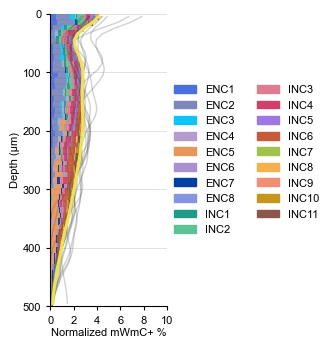

In [96]:
# --- Depth profile (per-sample normalization everywhere) ---
fig, ax = plot_depth_profile_with_composition_inside_line_PerSample_v2(
    adata_pan_wDepth,
    depth_key="depth_um",
    label_key="mWmC+",
    ct_col="cell_type",
    ct_color_key="cell_type_colors",
    group_key="samplename",
    normalize="within_group",
    composition_aggregation="mean_over_groups",
    composition_weighted=False,
    show_group_lines=True,
    x_max_percent=10,
    y_min_um=0,
    y_max_um=500,           # exact 0–500 lock
    y_tick_step=100,
    x_tick_step=2,
    legend=True,
    edge_lw=0,
    group_line_color="#4A4A4A",#,"#4A4A4A""#575859"
    box_aspect=2.5,
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="PAN_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0",
)


#### Fig 2d spatial mWmC+ cell distribution

In [219]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm
from pandas.api.types import CategoricalDtype

def boxplot_mwmc_depth_with_per_animal_enrichment_fill(
    adata,
    depth_col="depth_um",
    ct_col="cell_type_annotated_v2",
    group_col="animal",          # per-animal by default; can be "samplename"
    mwmc_key="mWmC+",
    include_celltypes=None,
    # figure / style
    figsize=None,                # if None, auto-computed to be tighter
    title="ENC / INC types",
    y_label="Pial distance (µm)",
    show_fliers=False,
    jitter_width=0.15,
    dot_size=14,
    x_label_rotation=90,         # rotation of x tick labels
    # colormap & median style
    cmap=None,                   # matplotlib colormap; if None, use default greys_rich
    median_color="black",
    box_edge_lw=2.0,             # box boundary linewidth (CT color)
    # y-axis limits
    y_max=500.0,                 # fix y-axis 0–y_max (0 at top); set None for auto
    # colormap cap (in percent of total mWmC+)
    max_enrichment_percent=None, # e.g. 20 → cap at 20%; None = use data max
    # colorbar tick positions (in percent)
    cbar_ticks_percent=None,     # e.g. [0, 10, 15]; if None, auto
    # saving
    save_path_pdf=None,
    save_path_png=None,
    dpi=600,
):
    """
    For each cell type:
      - Compute, per animal (or per group):
          enrichment_fraction_animal = (# mWmC+ cells of this CT in this animal)
                                       / (total mWmC+ cells in this animal)
      - Aggregate mean enrichment across animals and use it for box *fill* (via cmap).
      - Plot boxplots of per-animal median depth of mWmC+ cells.

    Box style:
      - Border color = cell-type color from adata.uns[f"{ct_col}_colors"].
      - Fill color   = cmap(mean_enrichment), with a colorbar legend.

    max_enrichment_percent:
      - If provided (e.g. 20), the colormap and legend are capped at that percent.
        Any mean enrichment >= cap is shown at the max color.

    cbar_ticks_percent:
      - Explicit tick locations on the colorbar in percent.
        Example: [0, 10, 15] → ticks at 0%, 10%, 15%.
    """

    # ===== default colormap if none provided =====
    if cmap is None:
        cmap = LinearSegmentedColormap.from_list(
            "greys_rich",
            [
                (0.00, "#ffffff"),
                (0.12, "#f7f7f7"),
                (0.30, "#e0e0e0"),
                (0.55, "#a0a0a0"),
                (0.80, "#5c5c5c"),  # dark grey, not pure black
                (1.00, "#262626"),  # very dark grey
            ]
        )

    # ===== Nature-style configs =====
    rcParams.update({
        "font.family": "Arial",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
    })

    color_key = f"{ct_col}_colors"

    # ---- guards ----
    for col in (ct_col, depth_col, group_col, mwmc_key):
        if col not in adata.obs.columns:
            raise KeyError(f"adata.obs['{col}'] not found.")
    if color_key not in adata.uns:
        raise KeyError(f"adata.uns['{color_key}'] not found.")

    # ===== Base obs table =====
    obs_all = adata.obs[[ct_col, group_col, depth_col, mwmc_key]].copy()
    obs_all[depth_col] = pd.to_numeric(obs_all[depth_col], errors="coerce")
    obs_all = obs_all.dropna(subset=[ct_col, group_col])

    mw = obs_all[mwmc_key]
    mw_bool = mw.astype(float).fillna(0) != 0
    obs_all["mwmc_bool"] = mw_bool

    obs_mw = obs_all[obs_all["mwmc_bool"]].copy()
    obs_mw = obs_mw.dropna(subset=[depth_col])
    if obs_mw.empty:
        raise ValueError("No mWmC+ cells with valid depth found.")

    # ===== Category order & CT colors =====
    ser_ct = adata.obs[ct_col]
    if isinstance(ser_ct.dtype, CategoricalDtype):
        cats_all = list(ser_ct.cat.categories)
    else:
        cats_all = sorted(ser_ct.unique().tolist())

    palette = list(map(str, adata.uns[color_key]))
    if len(palette) != len(cats_all):
        raise ValueError("Colors and categories length mismatch.")
    color_map = dict(zip(cats_all, palette))

    if include_celltypes is not None:
        include_set = set(map(str, include_celltypes))
        cats_all = [c for c in cats_all if str(c) in include_set]

    # ===== per-animal enrichment fractions =====
    per_animal_ct = (
        obs_mw.groupby([group_col, ct_col], observed=True)
        .size()
        .reset_index(name="n_mwmc_ct")
    )
    per_animal_total = (
        obs_mw.groupby(group_col, observed=True)
        .size()
        .reset_index(name="n_mwmc_total")
    )
    per_animal_ct = per_animal_ct.merge(per_animal_total, on=group_col, how="left")
    per_animal_ct["enrichment_fraction_animal"] = (
        per_animal_ct["n_mwmc_ct"] / per_animal_ct["n_mwmc_total"]
    )

    valid_cts = per_animal_ct[ct_col].unique().tolist()
    cats_all = [c for c in cats_all if c in valid_cts]
    if len(cats_all) == 0:
        raise ValueError("No cell types with mWmC+ cells across animals.")

    cats_enc = [c for c in cats_all if str(c).startswith("ENC")]
    cats_inc = [c for c in cats_all if str(c).startswith("INC")]
    cats_order = cats_enc + cats_inc

    # ===== aggregate enrichment across animals (mean ± SD) =====
    enrich_stats = (
        per_animal_ct.groupby(ct_col, observed=True)["enrichment_fraction_animal"]
        .agg(
            mean_enrichment="mean",
            sd_enrichment="std",
            n_animals="count"
        )
        .reset_index()
    )
    enrich_stats = enrich_stats.set_index(ct_col).reindex(cats_order)

    mean_vals = enrich_stats["mean_enrichment"].values.astype(float)

    # Determine color scale max (fraction, 0–1)
    data_max = np.nanmax(mean_vals) if np.size(mean_vals) > 0 else 0.0
    if not np.isfinite(data_max) or data_max <= 0:
        data_max = 1.0  # avoid degenerate norm

    if max_enrichment_percent is not None:
        vmax_frac = max_enrichment_percent / 100.0
        if vmax_frac <= 0:
            vmax_frac = data_max
    else:
        vmax_frac = data_max

    # 0–vmax_frac scale for colormap
    norm = Normalize(vmin=0.0, vmax=vmax_frac)
    fill_colors = [cmap(norm(v)) for v in mean_vals]
    edge_colors = [color_map[c] for c in cats_order]

    # ===== per-animal median depths of mWmC+ cells =====
    per_animal_depth = (
        obs_mw.groupby([ct_col, group_col], observed=True)[depth_col]
        .median()
        .reset_index()
    )

    data = [
        per_animal_depth.loc[per_animal_depth[ct_col] == c, depth_col].values
        for c in cats_order
    ]
    ns = [len(d) for d in data]

    # ===== dynamic, tighter figure width if not specified =====
    if figsize is None:
        w = max(4.0, 0.35 * len(cats_order))  # ~0.35" per box
        h = 4.6
        figsize = (w, h)

    fig, ax = plt.subplots(figsize=figsize)

    bp = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=cats_order,
        showfliers=show_fliers,
        widths=0.45,                 # slightly narrower boxes
        medianprops=dict(color=median_color, linewidth=1.2),
        whiskerprops=dict(color="#555555", linewidth=1.0),
        capprops=dict(color="#555555", linewidth=1.0),
        boxprops=dict(linewidth=box_edge_lw),
    )

    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(fill_colors[i])
        box.set_edgecolor(edge_colors[i])
        box.set_linewidth(box_edge_lw)

    rng = np.random.default_rng(0)
    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue
        x = i + (rng.random(len(vals)) - 0.5) * jitter_width
        ax.scatter(
            x,
            vals,
            s=dot_size,
            color=edge_colors[i - 1],
            alpha=0.6,
            edgecolor="white",
            linewidths=0.4,
            zorder=3,
        )

    # x tick labels with (n=) and rotation
    ha = "center" if x_label_rotation in (0, 360) else "right"
    ax.set_xticks(range(1, len(cats_order) + 1))
    ax.set_xticklabels(
        [f"{c}\n(n={n})" for c, n in zip(cats_order, ns)],
        rotation=x_label_rotation,
        ha=ha,
        va="top",
    )

    # ENC / INC divider
    if len(cats_enc) > 0 and len(cats_inc) > 0:
        split_pos = len(cats_enc) + 0.5
        ax.axvline(split_pos, linestyle="--", linewidth=0.8, color="#666666", alpha=0.7)
        ax.text((1 + len(cats_enc)) / 2.0, 1.02, "ENC",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=11)
        ax.text(len(cats_enc) + len(cats_inc) / 2.0 + 0.5, 1.02, "INC",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=11)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(title, pad=10)
    ax.set_ylabel(y_label)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

    # ---- y-axis: fixed 0–y_max (0 at top) if requested ----
    if y_max is not None:
        ax.set_ylim(float(y_max), 0.0)
    else:
        ymax_obs = float(np.nanmax(per_animal_depth[depth_col].values))
        ax.set_ylim(ymax_obs * 1.02, 0.0)

    # ---- colorbar legend for fill (enrichment) ----
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(
        "Mean mWmC+ fraction per cell type\n(fraction of total mWmC+ per animal)",
        fontsize=8
    )

    # ----- colorbar ticks in percent -----
    if cbar_ticks_percent is not None:
        tick_pcts = np.array(cbar_ticks_percent, dtype=float)
    elif max_enrichment_percent is not None:
        vmax_pct = float(max_enrichment_percent)
        # pick a “nice” integer step (5% for caps <= 25, else 10%)
        if vmax_pct <= 25:
            step = 5.0
        elif vmax_pct <= 60:
            step = 10.0
        else:
            step = 20.0
        tick_pcts = np.arange(0.0, vmax_pct + 1e-9, step)
    else:
        # fallback: 0, mid, max (in data space)
        tick_vals = np.linspace(0.0, data_max, 3)
        tick_pcts = tick_vals * 100.0

    tick_vals = tick_pcts / 100.0
    cbar.set_ticks(tick_vals)

    # format labels: integers if possible, else 1 decimal
    labels = []
    for p in tick_pcts:
        if abs(p - round(p)) < 1e-6:
            labels.append(f"{int(round(p))}%")
        else:
            labels.append(f"{p:.1f}%")
    cbar.set_ticklabels(labels)
    cbar.ax.tick_params(labelsize=8)

    fig.tight_layout()

    if save_path_pdf is not None:
        fig.savefig(save_path_pdf, bbox_inches="tight")
    if save_path_png is not None:
        fig.savefig(save_path_png, dpi=dpi, bbox_inches="tight")

    enrich_stats = enrich_stats.reset_index()
    enrich_stats["mean_enrichment_percent"] = enrich_stats["mean_enrichment"] * 100.0
    enrich_stats["sd_enrichment_percent"]   = enrich_stats["sd_enrichment"] * 100.0

    return fig, ax, enrich_stats


[info] Depth filter 0.0–500.0 µm on `depth_um`: 1181 → 1066 cells.


/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:90: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(ser):
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:208: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(vals):


Plot saved as:
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/pan_wga4_slide2_region_1_overlay_STRICTpalette_withLegend_v9.png
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/pan_wga4_slide2_region_1_overlay_STRICTpalette_withLegend_v9.pdf


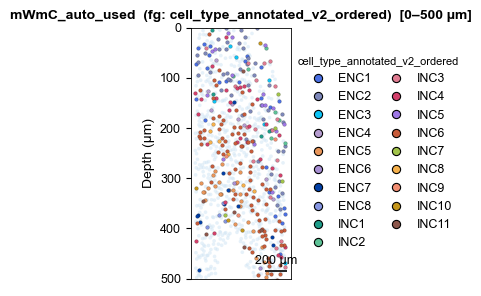

In [230]:
transform_csv = "/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/actual_RUN/PAN/202305181126_PanWGA4-P4-inj-slide2_VMSC01801/region_1/images/micron_to_mosaic_pixel_transform.csv"

cluster_small_multiples_oneslice_obs_new_mWmC_colorcelltype_COLORCORRECT(
    adata=adata_pan_wDepth,
    obs_key="cell_type",
    samplename="pan_wga4_slide2_region_1",
    ncols=1,
    pos_cols="mWmC+",
    front_color_by="cell_type",
    point_size=7,
    frameon=True,
    show_scalebar=True,
    scalebar_microns=200,
    scalebar_loc="upper right",
    save_path="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    edge_width=0.12,
    transform_csv_path=transform_csv,
    show_depth_ticks=True,
    depth_range_um=(0, 500),
    depth_ticks=(0, 500, 100),
    lock_ylim_to_depth_range=True,
    box_aspect=2.5,
    plot_prefix="pan_wga4_slide2_region_1_overlay_STRICTpalette_withLegend_v9",
    depth_direction="bottom_to_top",
    show_legend=True,
    legend_title="cell_type_annotated_v2_ordered",
    legend_cols=2,
    legend_fontsize=9,
    legend_marker_size=35,
    background_color="#cfe4f4",
    legend_loc="center left",
    legend_bbox=(1.02, 0.5)
)


In [132]:
from matplotlib.colors import LinearSegmentedColormap

reds_rich = LinearSegmentedColormap.from_list(
    "reds_rich",
    [
        (0.00, "#ffffff"),  # background
        (0.12, "#fef5f0"),  # very pale
        (0.30, "#fdcab5"),  # light peach
        (0.55, "#f67d4b"),  # orange
        (0.80, "#e13526"),  # strong red
        (1.00, "#7f0000"),  # deep red / maroon
    ]
)


In [154]:
from matplotlib.colors import LinearSegmentedColormap

greys_rich = LinearSegmentedColormap.from_list(
    "greys_rich",
    [
        (0.00, "#ffffff"),  # pure white (background)
        (0.12, "#f7f7f7"),  # very light grey
        (0.30, "#e0e0e0"),  # light grey
        (0.55, "#a0a0a0"),  # mid grey
        (0.80, "#505050"),  # dark grey
        (1.00, "#000000"),  # true black (max density)
    ]
)


In [140]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata,
    mwmc_key="mWmC+",   # or "mWmC+"
    depth_col="depth_um",
    group_key="samplename",         # or "animal"
    depth_range_um=None,            # e.g. (0, 500) or None for full
    drop_na_depth=True,
    bin_width=25,                   # µm per depth bin
    density_mode="fraction_of_total",   # "fraction_of_total" or "fraction_within_bin"
    aggregation="mean_over_groups",     # "mean_over_groups" or "pooled"
    aggregation_weighted=False,         # if mean_over_groups: weight by per-group counts
    cmap=None,                          # e.g. reds_rich; if None, use "Greys"
    figsize=(1.6, 3.5),             # tall, thin strip
    y_label="Depth (µm)",
    title=None,
    show_colorbar=True,
    cbar_label=None,                # auto if None
    # ---- NEW: scaling / comparability ----
    use_percent=True,               # plot as % (0–100) instead of fraction (0–1)
    vmax_percent=None,              # e.g. 20 -> cap colors at 20%; shared across datasets
    save_dir=None,
    save_prefix=None,
    dpi=600,
    transparent=True,
):
    """
    Depth density 'layer strip' for mWmC+ cells, aggregated across groups.

    - Groups by `group_key` (e.g. samplename or animal).
    - For each group:
        * Bin depths into [bin_width] µm bins.
        * density_mode="fraction_of_total":
              values_g[bin] = (# mWmC+ in bin) / (total mWmC+ in that group)
          density_mode="fraction_within_bin":
              values_g[bin] = (# mWmC+ in bin) / (# all cells in bin for that group)
    - Then aggregates across groups:
        * aggregation="mean_over_groups":
              mean of values_g across groups (optionally weighted).
        * aggregation="pooled":
              compute counts pooled across groups, then same formulas as above.
    - Plots as a vertical strip: y = depth (0 at top), x is dummy (0–1).

    NEW:
    - If use_percent=True, values are converted to percentages.
    - vmax_percent can be set (e.g. 20) so that the color scale is fixed
      from 0 to vmax_percent across datasets; any bin above that is clipped
      to the top color.
    """

    # ---- Nature-style rcParams ----
    mpl.rcParams.update({
        "font.family": "Arial",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    if cmap is None:
        cmap = plt.get_cmap("Greys")

    # ---- guard columns ----
    for col in (depth_col, mwmc_key, group_key):
        if col not in adata.obs.columns:
            raise KeyError(f"adata.obs['{col}'] not found.")

    # ---- pull obs and clean depth ----
    obs = adata.obs[[depth_col, mwmc_key, group_key]].copy()
    obs[depth_col] = pd.to_numeric(obs[depth_col], errors="coerce")
    if drop_na_depth:
        obs = obs.dropna(subset=[depth_col])
    if obs.empty:
        raise ValueError("No cells with valid depth.")

    # ---- depth range ----
    if depth_range_um is not None:
        dmin, dmax = map(float, depth_range_um)
    else:
        dmin = float(np.nanmin(obs[depth_col].values))
        dmax = float(np.nanmax(obs[depth_col].values))

    dmin_edge = np.floor(dmin / bin_width) * bin_width
    dmax_edge = np.ceil(dmax / bin_width) * bin_width
    bins = np.arange(dmin_edge, dmax_edge + bin_width, bin_width)
    n_bins = len(bins) - 1

    # ---- mWmC+ boolean mask ----
    mw = obs[mwmc_key]
    if mw.dtype == bool:
        mw_bool_all = mw
    else:
        mw_bool_all = mw.astype(float).fillna(0) != 0

    # ---- per-group stats ----
    group_vals = obs[group_key].astype(str)
    unique_groups = pd.unique(group_vals)

    per_group_values = []   # each: array (n_bins,) of fractions
    per_group_weights = []  # e.g. total mWmC+ for weighting
    pooled_pos_counts = np.zeros(n_bins, dtype=float)
    pooled_all_counts = np.zeros(n_bins, dtype=float)

    for g in unique_groups:
        g_mask = (group_vals == g)
        sub = obs[g_mask]
        if sub.empty:
            continue

        depths_g = sub[depth_col].values
        mw_bool_g = mw_bool_all[g_mask]

        # counts of positives and all cells in each bin
        pos_counts_g, _ = np.histogram(depths_g[mw_bool_g], bins=bins)
        all_counts_g, _ = np.histogram(depths_g, bins=bins)

        if density_mode == "fraction_within_bin":
            with np.errstate(divide="ignore", invalid="ignore"):
                vals_g = pos_counts_g / all_counts_g
                vals_g[~np.isfinite(vals_g)] = 0.0
            weight_g = all_counts_g.sum()
        else:  # "fraction_of_total"
            total_pos_g = pos_counts_g.sum()
            if total_pos_g == 0:
                # no mWmC+ in this group: include as zeros but zero weight
                vals_g = np.zeros_like(pos_counts_g, dtype=float)
                weight_g = 0.0
            else:
                vals_g = pos_counts_g.astype(float) / total_pos_g
                weight_g = total_pos_g

        per_group_values.append(vals_g)
        per_group_weights.append(weight_g)

        # pooled counts
        pooled_pos_counts += pos_counts_g
        pooled_all_counts += all_counts_g

    if len(per_group_values) == 0:
        raise ValueError("No usable groups for depth density aggregation.")

    per_group_values = np.vstack(per_group_values)
    per_group_weights = np.array(per_group_weights, dtype=float)

    # ---- aggregate across groups (still in fractional units 0–1) ----
    if aggregation == "pooled":
        if density_mode == "fraction_within_bin":
            with np.errstate(divide="ignore", invalid="ignore"):
                values = pooled_pos_counts / pooled_all_counts
                values[~np.isfinite(values)] = 0.0
        else:  # "fraction_of_total"
            total_pos = pooled_pos_counts.sum()
            if total_pos == 0:
                raise ValueError("Total pooled mWmC+ count is zero.")
            values = pooled_pos_counts.astype(float) / total_pos
    else:  # "mean_over_groups"
        if aggregation_weighted:
            # weighted mean, weights based on group totals
            w = per_group_weights
            w = np.where(w < 0, 0, w)
            if w.sum() == 0:
                # fall back to unweighted mean if all weights are zero
                values = np.nanmean(per_group_values, axis=0)
            else:
                values = np.average(per_group_values, axis=0, weights=w)
        else:
            values = np.nanmean(per_group_values, axis=0)

    # ---- convert to percent & clip with vmax_percent ----
    if use_percent:
        values_plot = values * 100.0  # 0–100 (%)
        # choose vmax (percent)
        if vmax_percent is not None:
            vmax_plot = float(vmax_percent)
        else:
            vmax_plot = float(np.nanmax(values_plot))
        if not np.isfinite(vmax_plot) or vmax_plot <= 0:
            vmax_plot = 1.0
        # clamp to [0, vmax_plot]
        values_plot = np.clip(values_plot, 0.0, vmax_plot)
        vmin, vmax = 0.0, vmax_plot
    else:
        # keep as fractions 0–1
        values_plot = values
        if vmax_percent is not None:
            # interpret vmax_percent as fraction (e.g. 0.2)
            vmax_plot = float(vmax_percent)
        else:
            vmax_plot = float(np.nanmax(values_plot))
        if not np.isfinite(vmax_plot) or vmax_plot <= 0:
            vmax_plot = 0.1
        values_plot = np.clip(values_plot, 0.0, vmax_plot)
        vmin, vmax = 0.0, vmax_plot

    # ---- 2D array for pcolormesh: (n_bins × 1) ----
    Z = values_plot.reshape(-1, 1)  # one column, each row = depth bin

    x_edges = np.array([0.0, 1.0])  # dummy x from 0 to 1
    y_edges = bins

    # ---- figure / axis ----
    fig, ax = plt.subplots(figsize=figsize)

    pc = ax.pcolormesh(
        x_edges,
        y_edges,
        Z,
        cmap=cmap,
        shading="flat",
        vmin=vmin,
        vmax=vmax,  # ensures shared scale across datasets if vmax_percent fixed
    )

    # dummy x-axis
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_xlabel("")

    # y-axis: depth, 0 at top
    ax.set_ylabel(y_label)
    ax.set_ylim(y_edges[-1], y_edges[0])  # invert so 0 is at top

    # nice y-ticks
    ymax = y_edges[-1]
    ymin = y_edges[0]
    tick_step = 100.0 if bin_width <= 50 else bin_width
    yticks = np.arange(
        np.floor(ymin / tick_step) * tick_step,
        np.ceil(ymax / tick_step) * tick_step + 1e-9,
        tick_step,
    )
    yticks = yticks[(yticks >= ymin) & (yticks <= ymax)]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(t)}" for t in yticks])

    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

    # ---- title ----
    if title is None:
        if aggregation == "pooled":
            agg_str = "pooled"
        else:
            agg_str = "mean over groups"
        if density_mode == "fraction_of_total":
            dm_str = "fraction of total mWmC+"
        else:
            dm_str = "fraction mWmC+ within bin"
        title = f"{dm_str}\n({agg_str}, n={len(per_group_values)})"
    ax.set_title(title, fontsize=9)

    # ---- colorbar legend ----
    if show_colorbar:
        cbar = fig.colorbar(pc, ax=ax, fraction=0.08, pad=0.03)

        # default label
        if cbar_label is None:
            if use_percent:
                cbar_label = "Normalized mWmC+ (%)"
            else:
                if density_mode == "fraction_of_total":
                    cbar_label = "Fraction of total mWmC+"
                else:
                    cbar_label = "Fraction mWmC+ within bin"
        cbar.ax.set_ylabel(cbar_label, fontsize=8)

        # explicit ticks including 0
        if use_percent:
            # choose a sensible tick step (e.g. 5 for vmax >= 15, else divide range)
            if vmax <= 10:
                step = max(1, round(vmax / 3.0))
            else:
                step = 5.0
            ticks = np.arange(0.0, vmax + 1e-9, step)
            if ticks[-1] != vmax:
                ticks[-1] = vmax
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([f"{t:.0f}" for t in ticks])
        else:
            # fraction scale: 0–vmax
            ticks = np.linspace(0.0, vmax, 4)
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

        cbar.ax.tick_params(labelsize=8)

    fig.tight_layout()

    # ---- saving ----
    if save_dir and save_prefix:
        os.makedirs(save_dir, exist_ok=True)
        png_path = os.path.join(save_dir, f"{save_prefix}.png")
        pdf_path = os.path.join(save_dir, f"{save_prefix}.pdf")
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight", transparent=transparent)
        fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight", transparent=transparent)
        print(f"Saved depth density strip (across groups):\n  • {png_path}\n  • {pdf_path}")

    return fig, ax


Saved depth density strip (across groups):
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Pan_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Pan_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.pdf


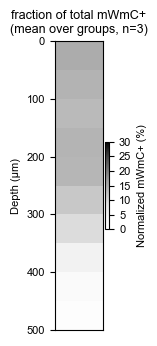

In [155]:
fig, ax = plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata_pan,
    mwmc_key="mWmC+",
    depth_col="depth_um",
    group_key="animal",
    depth_range_um=(0, 500),
    bin_width=50,
    density_mode="fraction_of_total",
    aggregation="mean_over_groups",
    use_percent=True,
    vmax_percent=30,                 # <- cap at 20%, shared across all datasets
    cmap=greys_rich,                  
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="TransAMERFISH_Pan_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30",
)


Saved depth density strip (across groups):
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Kcng_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Kcng_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.pdf


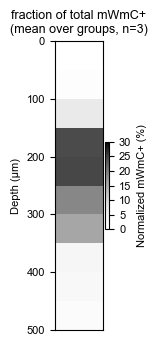

In [157]:
fig, ax = plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata_kcng,
    mwmc_key="mWmC+",
    depth_col="depth_um",
    group_key="animal",
    depth_range_um=(0, 500),
    bin_width=50,
    density_mode="fraction_of_total",
    aggregation="mean_over_groups",
    use_percent=True,
    vmax_percent=30,                 # <- cap at 20%, shared across all datasets
    cmap=greys_rich,                 
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="TransAMERFISH_Kcng_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30",
)


Saved depth density strip (across groups):
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Cart_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Cart_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.pdf


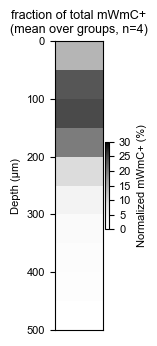

In [159]:
fig, ax = plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata_cart,
    mwmc_key="mWmC+",
    depth_col="depth_um",
    group_key="animal",
    depth_range_um=(0, 500),
    bin_width=50,
    density_mode="fraction_of_total",
    aggregation="mean_over_groups",
    use_percent=True,
    vmax_percent=30,                 # <- cap at 20%, shared across all datasets
    cmap=greys_rich,                 
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="TransAMERFISH_Cart_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30",
)


Saved depth density strip (across groups):
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Foxp2_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Foxp2_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.pdf


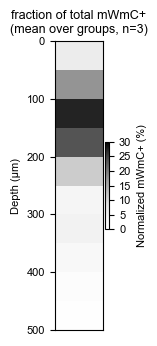

In [160]:
fig, ax = plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata_foxp2,
    mwmc_key="mWmC+",
    depth_col="depth_um",
    group_key="animal",
    depth_range_um=(0, 500),
    bin_width=50,
    density_mode="fraction_of_total",
    aggregation="mean_over_groups",
    use_percent=True,
    vmax_percent=30,                 # <- cap at 20%, shared across all datasets
    cmap=greys_rich,                  
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="TransAMERFISH_Foxp2_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30",
)


Saved depth density strip (across groups):
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Tusc5_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/TransAMERFISH_Tusc5_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30.pdf


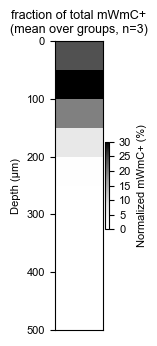

In [161]:
fig, ax = plot_mwmc_depth_density_1d_across_groups_fixcap(
    adata_tusc5,
    mwmc_key="mWmC+",
    depth_col="depth_um",
    group_key="animal",
    depth_range_um=(0, 500),
    bin_width=50,
    density_mode="fraction_of_total",
    aggregation="mean_over_groups",
    use_percent=True,
    vmax_percent=30,                 # <- cap at 20%, shared across all datasets
    cmap=greys_rich,                  # your rich red colormap
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="TransAMERFISH_Tusc5_AllSamples_mWmC_depth_density_fractionOfTotal_meanOverAnimals_v1_Bin50_grey_rich_0_30",
)


### Fig2f

/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby([group_key, 'bin', ct_col])
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb.groupby([group_key, 'bin'])['n']
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:162: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current 

Saved:
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/KCNG_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/KCNG_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.pdf


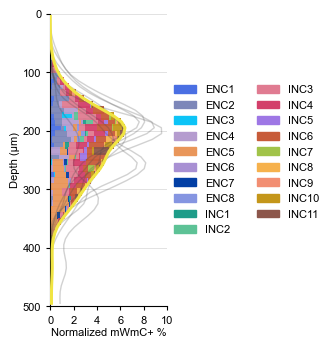

In [170]:
# --- Depth profile (per-sample normalization everywhere) ---
fig, ax = plot_depth_profile_with_composition_inside_line_PerSample_v2(
    adata_kcng,
    depth_key="depth_um",
    label_key="mWmC+",
    ct_col="cell_type",
    ct_color_key="cell_type_colors",
    group_key="samplename",
    normalize="within_group",
    composition_aggregation="mean_over_groups",
    composition_weighted=False,
    show_group_lines=True,
    x_max_percent=10,
    y_min_um=0,
    y_max_um=500,           # exact 0–500 lock
    y_tick_step=100,
    x_tick_step=2,
    legend=True,
    edge_lw=0,
    group_line_color="#4A4A4A",#,"#4A4A4A""#575859"
    box_aspect=2.5,
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="KCNG_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0",
)


chordiagram matrice

[info] Depth filter 0.0–500.0 µm on `depth_um`: 733 → 728 cells.


/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:90: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(ser):
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:208: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(vals):


Plot saved as:
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/tusc5_cl049_region_0_mWmC_overlay_blackforeground_full_boxaspect125_COLOR_REPLOT_VECTORIZED_COLORCORRECT_mWmCManual_v9.png
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/tusc5_cl049_region_0_mWmC_overlay_blackforeground_full_boxaspect125_COLOR_REPLOT_VECTORIZED_COLORCORRECT_mWmCManual_v9.pdf


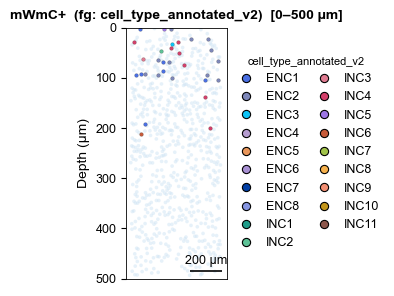

In [57]:
###### TUSC5: tusc5_cl033_2_region_6

transform_csv = "/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/actual_RUN/TUSC5/Tusc5_CL049/region_0/images/micron_to_mosaic_pixel_transform.csv"

cluster_small_multiples_oneslice_obs_new_mWmC_colorcelltype_COLORCORRECT(
    adata=adata_tusc5,
    obs_key="cell_type",
    front_color_by='cell_type',
    samplename="tusc5_cl049_region_0",    # use exact or a distinctive substring
    ncols=1,
    pos_cols="mWmC+",   
    #front_color_by='cell_type_annotated_v2',
    #pos_color="black", # red positives on grey background
    point_size=7,                      # <- adjust cell size here (points^2)
    frameon=True,                        # <- show a thin frame
    show_scalebar=True,
    background_color="#cfe4f4",
    scalebar_microns=200,                # default is 200 µm, change as needed
    scalebar_loc="upper right",
    save_path="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    edge_width=0.12,
    transform_csv_path=transform_csv,
    show_depth_ticks=True,
    depth_range_um=(0, 500),          # <- hard lock range
    depth_ticks=(0, 500, 100),        # ticks to match the profile
    lock_ylim_to_depth_range=True,    # <- IMPORTANT: exact 0–500 lock
    box_aspect=2.5,
    plot_prefix="tusc5_cl049_region_0_mWmC_overlay_blackforeground_full_boxaspect125_COLOR_REPLOT_VECTORIZED_COLORCORRECT_mWmCManual_v9",
    depth_direction="bottom_to_top",
    show_legend=True,
    legend_title="cell_type",
    legend_cols=2,
    legend_fontsize=9,
    legend_marker_size=35,
    legend_loc="center left",
    legend_bbox=(1.02,0.5)
)


/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby([group_key, 'bin', ct_col])
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb.groupby([group_key, 'bin'])['n']
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:162: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current 

Saved:
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/Tusc5_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/Tusc5_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.pdf


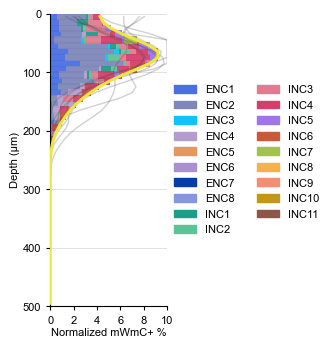

In [171]:
# --- Depth profile (per-sample normalization everywhere) ---
fig, ax = plot_depth_profile_with_composition_inside_line_PerSample_v2(
    adata_tusc5,
    depth_key="depth_um",
    label_key="mWmC+",
    ct_col="cell_type",
    ct_color_key="cell_type_colors",
    group_key="samplename",
    normalize="within_group",
    composition_aggregation="mean_over_groups",
    composition_weighted=False,
    show_group_lines=True,
    x_max_percent=10,
    y_min_um=0,
    y_max_um=500,           # exact 0–500 lock
    y_tick_step=100,
    x_tick_step=2,
    legend=True,
    edge_lw=0,
    group_line_color="#4A4A4A",#,"#4A4A4A""#575859"
    box_aspect=2.5,
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="Tusc5_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0",
)


[info] Depth filter 0.0–500.0 µm on `depth_um`: 1423 → 783 cells.


/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:90: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(ser):
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/1421977727.py:208: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(vals):


Plot saved as:
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/cart_676I2_region_4_mWmC_overlay_blackforeground_full_boxaspect125_v2_COLOR_REPLOT_VECTORIZED_COLORCORRECT_v9_mWmC_auto_used_v2_V9.png
 - /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/cart_676I2_region_4_mWmC_overlay_blackforeground_full_boxaspect125_v2_COLOR_REPLOT_VECTORIZED_COLORCORRECT_v9_mWmC_auto_used_v2_V9.pdf


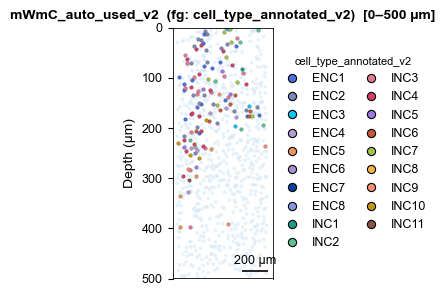

In [228]:
## CART: cart_676I2_region_4

## cart re-draw with smaller dot size
transform_csv = "/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/actual_RUN/CART/Cart/202208051435_Cart-dio-mWmC-676I2_VMSC01801/region_4/images/micron_to_mosaic_pixel_transform.csv"
# transform_csv = "/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/actual_RUN/Foxp2/FoxP2-toe3/region_1/images/micron_to_mosaic_pixel_transform.csv"

cluster_small_multiples_oneslice_obs_new_mWmC_colorcelltype_COLORCORRECT(
    adata=adata_cart,
    obs_key="cell_type",
    samplename="cart_676I2_region_4",    # use exact or a distinctive substring
    ncols=1,
    pos_cols="mWmC+", 
    front_color_by='cell_type',
    #pos_color="black", # red positives on grey background
    point_size=7,                      # <- adjust cell size here (points^2)
    frameon=True,                        # <- show a thin frame
    show_scalebar=True,
    scalebar_microns=200,                # default is 200 µm, change as needed
    scalebar_loc="upper right",
    save_path="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
     edge_width=0.12,
    transform_csv_path=transform_csv,
    show_depth_ticks=True,
    depth_range_um=(0, 500),          # <- hard lock range
    depth_ticks=(0, 500, 100),        # ticks to match the profile
    lock_ylim_to_depth_range=True,    # <- IMPORTANT: exact 0–500 lock
    box_aspect=2.5,
    plot_prefix="cart_676I2_region_4_mWmC_overlay_blackforeground_full_boxaspect125_v2_COLOR_REPLOT_VECTORIZED_COLORCORRECT_v9_mWmC_auto_used_v2_V9",
    depth_direction="bottom_to_top",
    show_legend=True,
    legend_title="cell_type",
    legend_cols=2,
    legend_fontsize=9,
    background_color="#cfe4f4",
    legend_marker_size=35,
    legend_loc="center left",
    legend_bbox=(1.02,0.5)
)


/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby([group_key, 'bin', ct_col])
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb.groupby([group_key, 'bin'])['n']
/var/folders/yw/j3fcdghn3nnb9cgzc17f64j40000gn/T/ipykernel_38163/787756137.py:162: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current 

Saved:
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/Cart_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.png
  • /Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT/Cart_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0.pdf


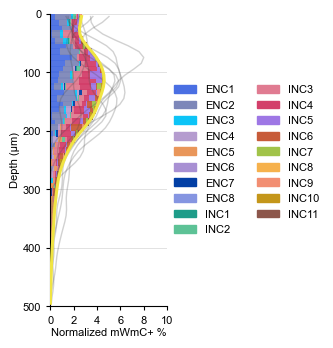

In [172]:
# --- Depth profile (per-sample normalization everywhere) ---
fig, ax = plot_depth_profile_with_composition_inside_line_PerSample_v2(
    adata_cart,
    depth_key="depth_um",
    label_key="mWmC+",
    ct_col="cell_type",
    ct_color_key="cell_type_colors",
    group_key="samplename",
    normalize="within_group",
    composition_aggregation="mean_over_groups",
    composition_weighted=False,
    show_group_lines=True,
    x_max_percent=10,
    y_min_um=0,
    y_max_um=500,           # exact 0–500 lock
    y_tick_step=100,
    x_tick_step=2,
    legend=True,
    edge_lw=0,
    group_line_color="#4A4A4A",#,"#4A4A4A""#575859"
    box_aspect=2.5,
    save_dir="/Users/linzhang1/Documents/Duan_Lab/Data/mWmC_mask_RFP/mWmC_registration_Auto/HPC_mWmC_Auto_Registration_Results/PLOT",
    save_prefix="Cart_mWmC_depth_perSampleNorm_meanLine_andComp_Ratio2_5_REPLOT_v9_4A4A4A_edge_lw0",
)
